# Модели кластеризации на примере обработки изображений японских иероглифов

Требования для сдачи лабораторной работы:
1. Использовать набор данных стандарта MNIST
2. Анализ датасета
3. Доработка датасета (устранение пробелов, новые признаки, преобразование выбросов, стандартизация или другое...)
4. Анализ каждого класса по отдельности
5. Применение пары методов понижения размерности
...

## Библиотеки

In [124]:
# Импорт библиотек
from dotenv import load_dotenv
import os

from scipy.io import arff
from PIL import Image
import numpy as np
import pandas as pd
import openml
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns
import ipywidgets as widgets
import plotly.express as px

## Скачивание и загрузка датасета Kuzushiji-MNIST

In [2]:
# Установка библиотеки openml
%pip install openml

Note: you may need to restart the kernel to use updated packages.


### Импорт ключа API из .env файла

In [3]:
 # Загружаем переменные окружения из .env файла
print("Переменные окружения загружены из .env файла") if load_dotenv() else print("Не удалось загрузить переменные окружения из .env файла")

Переменные окружения загружены из .env файла


### Пробуем загрузить датасет через библиотеку openml

~~Первый метод загрузки (через API Openml) не работает 10 мая 2026 года. Поэтому он будет закомментирован.~~

Иногда openml может упасть и его сервера отдадут 504 ошибку.

In [4]:
# Загрузка датасета по названию
openml_api_key = os.getenv("OPENML_API_KEY")
openml.config.apikey = openml_api_key

df = openml.datasets.get_dataset("Kuzushiji-MNIST")
df

OpenML Dataset
Name.........: Kuzushiji-MNIST
Version......: 1
Format.......: arff
Upload Date..: 2019-07-23 11:27:57
Licence......: CC BY-SA 4.0
Download URL.: https://openml.org/data/v1/download/21388379/Kuzushiji-MNIST.arff
OpenML URL...: https://www.openml.org/d/41982
# of features: None

### Загружаем датасет через файл

In [5]:
df_arff = arff.loadarff("dataset.arff")
df = pd.DataFrame(df_arff[0])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 785 entries, pixel-0000 to class
dtypes: float64(784), object(1)
memory usage: 419.2+ MB


### Первые 5 столбцов данных

In [6]:
df.head(5)

,pixel-0000,pixel-0001,pixel-0002,pixel-0003,pixel-0004,pixel-0005,pixel-0006,pixel-0007,pixel-0008,pixel-0009,...,pixel-0775,pixel-0776,pixel-0777,pixel-0778,pixel-0779,pixel-0780,pixel-0781,pixel-0782,pixel-0783,class
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,255.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'8'
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'7'
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'0'
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0,164.0,...,64.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'1'
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'4'


## Изучение датасета

In [7]:
plt.style.use('dark_background') # тёмная тема 😎

### Данные

In [8]:
print(f"Один пиксель изображения кодируется {df.iloc[:, :-1].max().max().astype(int) + 1} уровнями цвета")

Один пиксель изображения кодируется 256 уровнями цвета


То есть для иероглифов используется 8 битовое кодирование. **Но мы нормализуем до 0–1.**

#### Нормализация

In [9]:
df.loc[:, df.columns != "class"] = df.loc[:, df.columns != "class"].map(lambda pixel: pixel / 255)
df.head()

,pixel-0000,pixel-0001,pixel-0002,pixel-0003,pixel-0004,pixel-0005,pixel-0006,pixel-0007,pixel-0008,pixel-0009,...,pixel-0775,pixel-0776,pixel-0777,pixel-0778,pixel-0779,pixel-0780,pixel-0781,pixel-0782,pixel-0783,class
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,...,1.00000,0.352941,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'8'
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,...,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'7'
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,...,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'0'
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.12549,0.643137,...,0.25098,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'1'
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,...,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'4'


#### Количество классов и объектов

In [10]:
# число классов, размер изображений, количество объектов...
print(f"Число классов: {df['class'].nunique()}")
print(f"Размер изображений: {((df.shape[1] - 1) ** 0.5)}x{((df.shape[1] - 1) ** 0.5)} пикселей")
print(f"Количество объектов: {len(df)}")
print(f"Распределение классов: {df['class'].value_counts()}")

Число классов: 10
Размер изображений: 28.0x28.0 пикселей
Количество объектов: 70000
Распределение классов: class
b'8'    7000
b'7'    7000
b'0'    7000
b'1'    7000
b'4'    7000
b'2'    7000
b'5'    7000
b'6'    7000
b'9'    7000
b'3'    7000
Name: count, dtype: int64


In [11]:
df.describe()

,pixel-0000,pixel-0001,pixel-0002,pixel-0003,pixel-0004,pixel-0005,pixel-0006,pixel-0007,pixel-0008,pixel-0009,...,pixel-0774,pixel-0775,pixel-0776,pixel-0777,pixel-0778,pixel-0779,pixel-0780,pixel-0781,pixel-0782,pixel-0783
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,...,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,0.001181,0.002908,0.004901,0.008546,0.014484,0.023040,0.034406,0.049220,0.066455,0.085771,...,0.137775,0.101464,0.070721,0.048532,0.034255,0.024705,0.018041,0.012129,0.006317,0.001984
std,0.024143,0.040932,0.053898,0.072749,0.095138,0.119014,0.144879,0.172648,0.199640,0.225447,...,0.294409,0.257009,0.216744,0.179929,0.151380,0.127867,0.109283,0.089064,0.061907,0.029895
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.015686,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Типы данных

In [12]:
df.dtypes

pixel-0000    float64
pixel-0001    float64
pixel-0002    float64
pixel-0003    float64
pixel-0004    float64
               ...   
pixel-0780    float64
pixel-0781    float64
pixel-0782    float64
pixel-0783    float64
class          object
Length: 785, dtype: object

#### Назначение данных

##### Визуализация данных

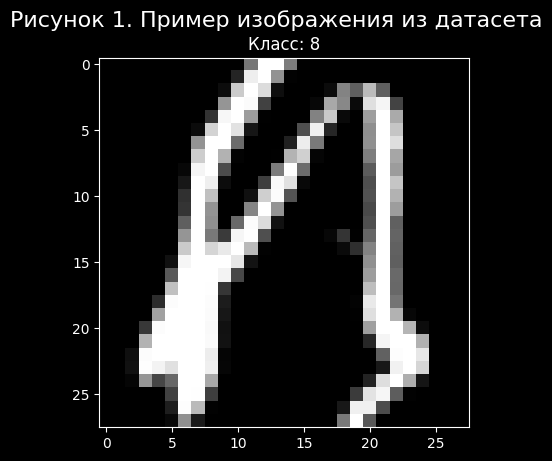

In [13]:
get_image = lambda row: row.drop('class').values.reshape(28, 28).astype(float)
get_label = lambda row: row['class'].decode("utf-8") if isinstance(row['class'], bytes) else row['class']

# Первая картинка в датасете
imgplot = get_image(df.iloc[0])
plt.imshow(imgplot, cmap="gray")
plt.title(f"Класс: {get_label(df.iloc[0])}")
plt.suptitle("Рисунок 1. Пример изображения из датасета", fontsize=16) # Тот же title только с отступом побольше
plt.show()

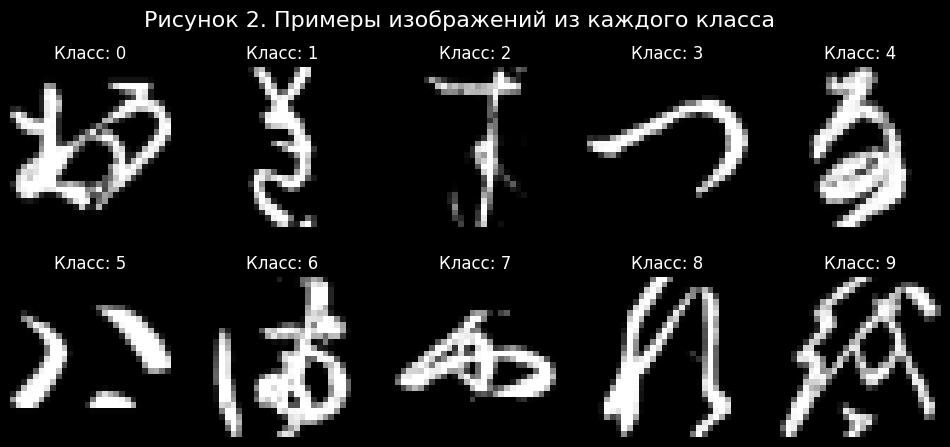

In [14]:
# Визуализация изображений
def show_df_classes(df: pd.DataFrame, header: str) -> None:
    df_each_class = df.groupby('class').first().reset_index()  # Получаем по одному примеру для каждого класса

    class_list_encoded = df['class'].unique()
    if isinstance(class_list_encoded[0], bytes):  # Проверяем, являются ли метки байтовыми строками
        class_list = [label.decode("utf-8") for label in class_list_encoded]
    else:
        class_list = class_list_encoded.tolist()
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(header, fontsize=16)

    for i, ax in enumerate(axes.flatten()): # оси сглажены в одномерный массив для вывода через imshow
        datapoint = df_each_class.iloc[i]
        label = get_label(datapoint)
        classes_to_show = class_list
        
        if label in classes_to_show: 
            ax.imshow(get_image(datapoint), cmap="gray")
            ax.set_title(f"Класс: {label}")
            ax.axis("off")
            classes_to_show.remove(label)

    plt.show()

show_df_classes(df, "Рисунок 2. Примеры изображений из каждого класса") 

##### Откуда данные

Сопоставим иероглифы с картинкой из оригинальной статьи, в которой, в том числе, описывается создание датасета https://arxiv.org/pdf/1812.01718. 

Также рассмотрим как эти иероглифы выглядят в современном японском письме (https://kanadojo.com/academy/complete-hiragana-chart-pronunciation).

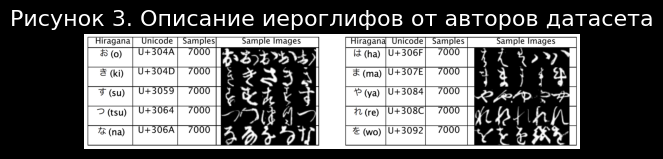

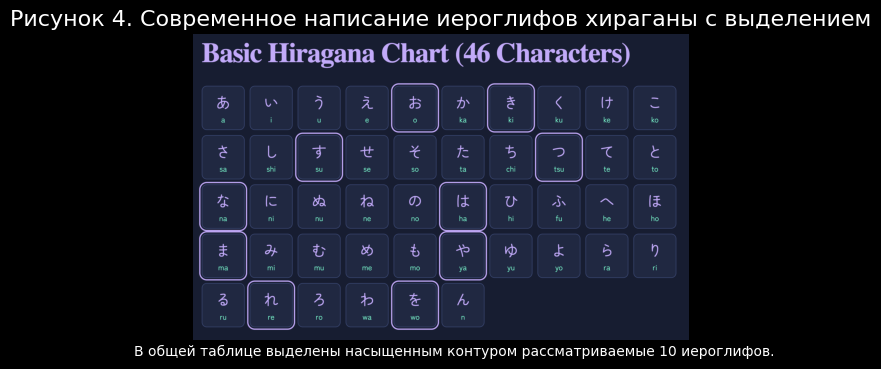

In [15]:
pwd = os.getcwd()

plt.imshow(np.asarray(Image.open(f'{pwd}/characters from reference paper.png')))
plt.axis("off")
plt.title("Рисунок 3. Описание иероглифов от авторов датасета", fontsize=16)
plt.show()

# Источник: https://kanadojo.com/academy/complete-hiragana-chart-pronunciation
plt.imshow(np.asarray(Image.open(f"{pwd}/Hiragana Chart with highlighted characters.png")))
plt.text(-250, 1370,"В общей таблице выделены насыщенным контуром рассматриваемые 10 иероглифов.")
plt.axis("off")
plt.title("Рисунок 4. Современное написание иероглифов хираганы с выделением", fontsize=16)
plt.show()

### Переименование классов

Наименование классов будет без самих иероглифов, так как есть проблемы с отображением в MatPlotLib без загрузки и установки нестандартных шрифтов.

In [16]:
# Маппинг числовых меток Kuzushiji-MNIST на иероглифы хираганы
# kuzushiji_classes = {
#     '0': 'お(o)', '1': 'き(ki)', '2': 'す(su)', '3': 'つ(tsu)', '4': 'な(na)',
#     '5': 'は(ha)', '6': 'ま(ma)', '7': 'や(ya)', '8': 'れ(re)', '9': 'を(wo)'
# }

kuzushiji_classes = {
    '0': 'o', '1': 'ki', '2': 'su', '3': 'tsu', '4': 'na',
    '5': 'ha', '6': 'ma', '7': 'ya', '8': 're', '9': 'wo'
}


df['class'] = df['class'].str.decode('utf-8').map(kuzushiji_classes)
df['class'].unique()

<ArrowStringArray>
['re', 'ya', 'o', 'ki', 'na', 'su', 'ha', 'ma', 'wo', 'tsu']
Length: 10, dtype: str

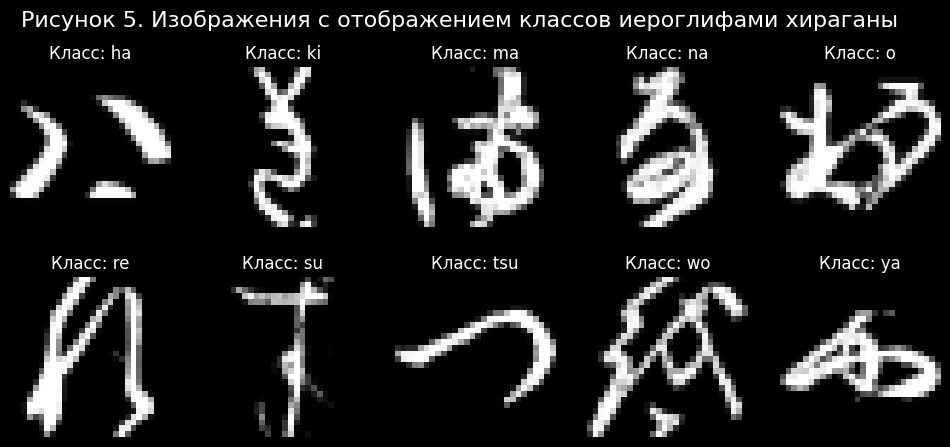

In [17]:
show_df_classes(df, "Рисунок 5. Изображения с отображением классов иероглифами хираганы")

### Проверка на пропущенные значения

In [18]:
if df.isna().sum().max() > 0:
    print("В датасете есть пропущенные значения.")
else:
    print("В датасете нет пропущенных значений.")

В датасете нет пропущенных значений.


### Хаотичность пикселей на изображениях 

Text(0.5, 1.02, 'Рисунок 6. Парные диаграммы для 5 центральных пикселей изображений')

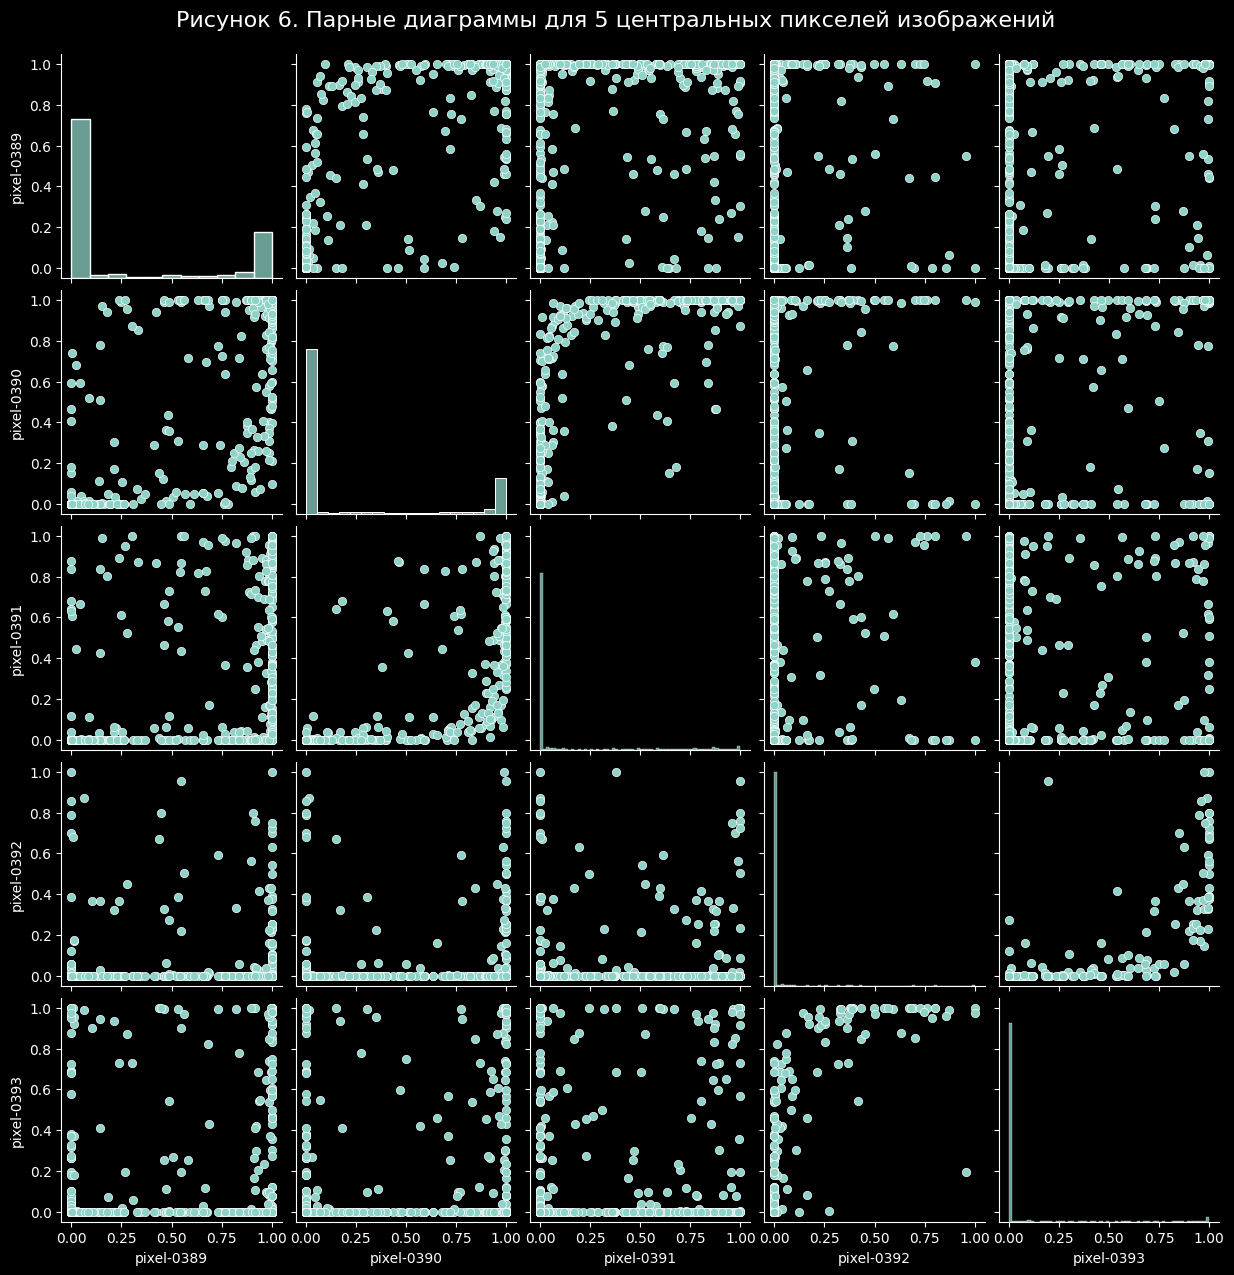

In [19]:
df_cp = df.loc[0:1000, 'pixel-0389':'pixel-0393'].copy()
pairplot_central = sns.pairplot(df_cp)
pairplot_central.figure.suptitle("Рисунок 6. Парные диаграммы для 5 центральных пикселей изображений", fontsize=16, y=1.02)

Центральные пиксели (pixel-0389 - pixel-393) принимают разнообразные значения в центре. 

Увеличение разнообразия увеличивает дисперсию признака. 

Следовательно для метода главных компонент (PCA), они будут важны.

Text(0.5, 1.02, 'Рисунок 7. Парные диаграммы для 5 угловых пикселей изображений')

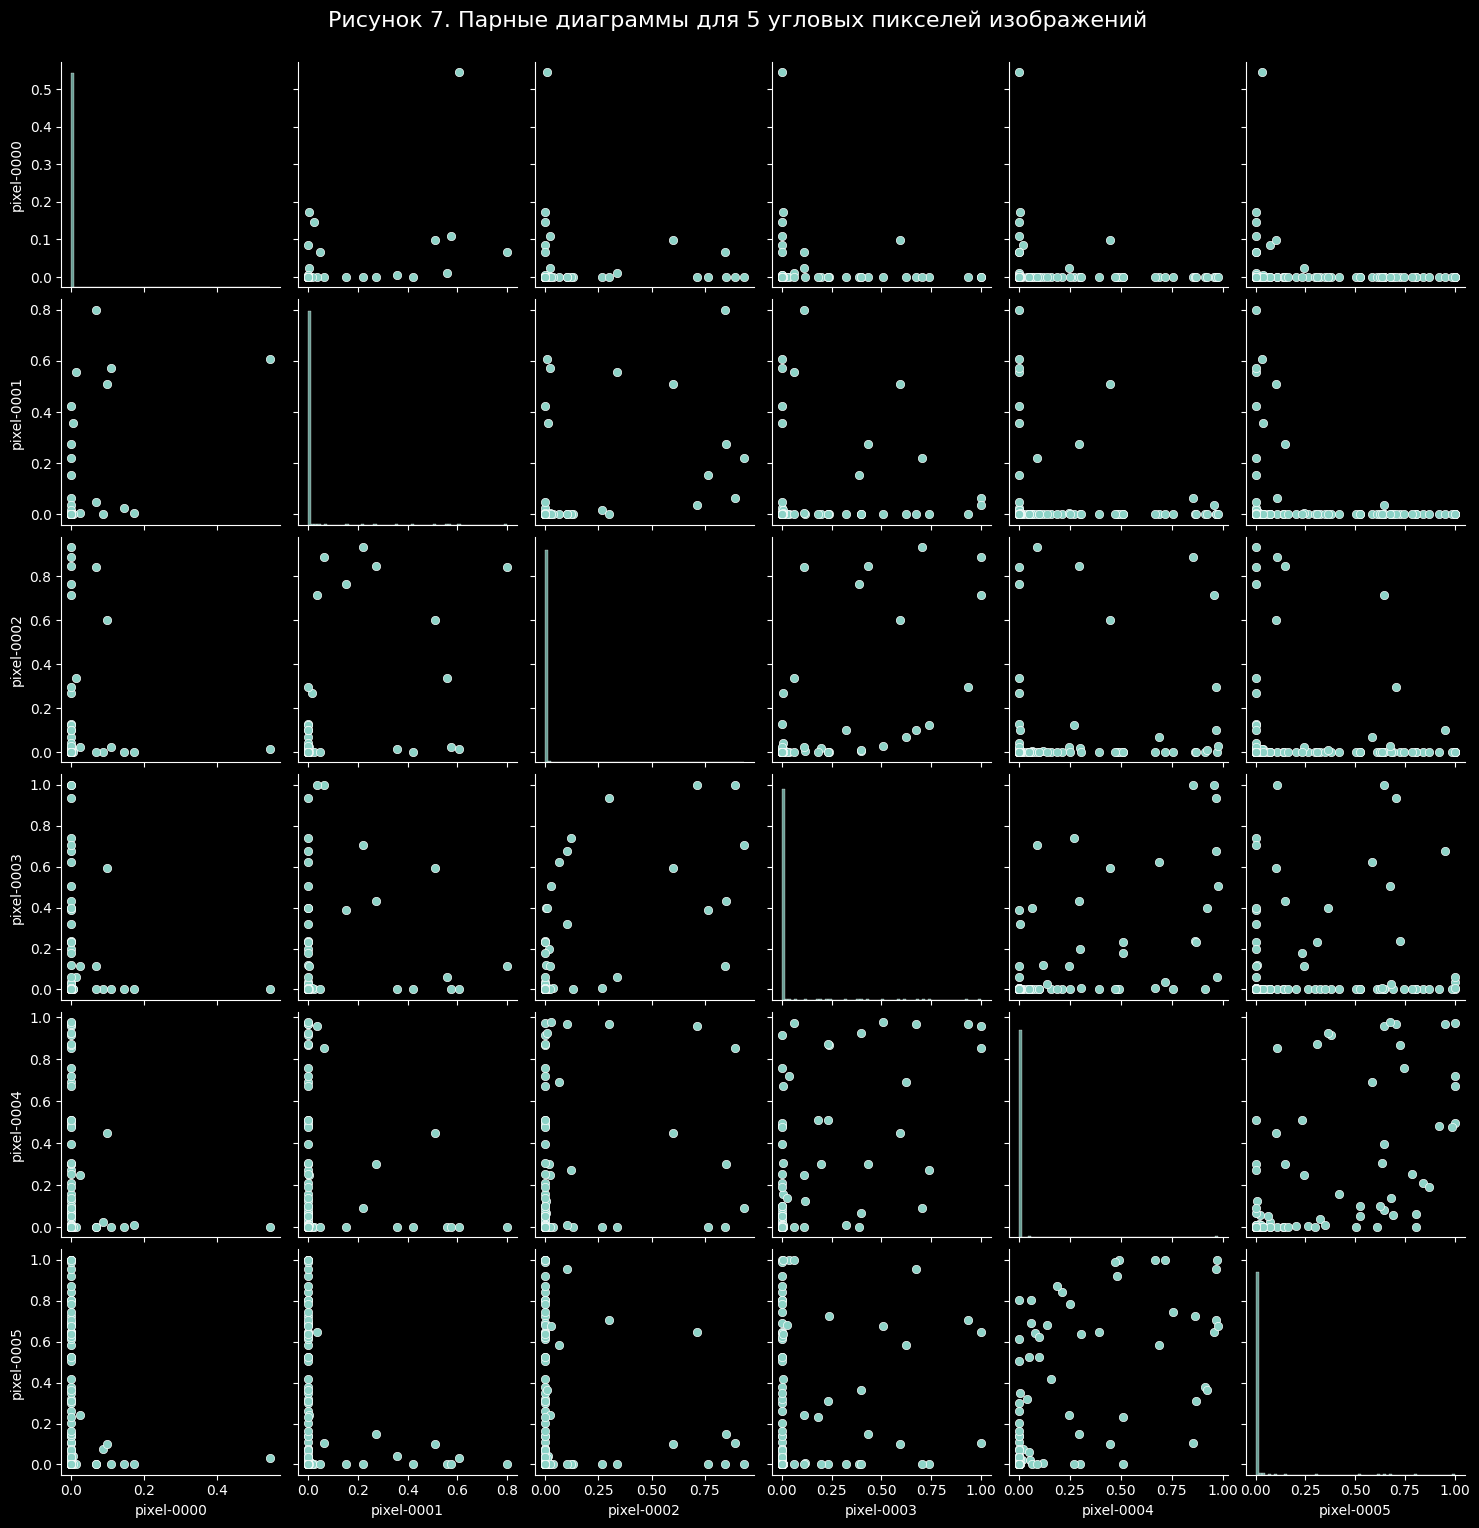

In [20]:
df_cp = df.loc[0:1000, 'pixel-0000':'pixel-0005'].copy()
pairplot_corners = sns.pairplot(df_cp)
pairplot_corners.figure.suptitle("Рисунок 7. Парные диаграммы для 5 угловых пикселей изображений", fontsize=16, y=1.02)

В углах изображений почти всегда нулевые значения яркости пикселей. Это видно по диагональным столбчатым диаграммам. 

По остальным диаграммам видно, что пиксели могут принимать отличные от нуля значения, но меняются менее интенсивно (точки смещены в левый нижний угол) по сравнению с центральными пикселями (точки смещены в правый верхний угол).

Так как точки в углах менее разнообразны это уменьшает итоговую дисперсию признака. Пониженные показатели дисперсии угловых пикселей будут меньше влиять при выборе главных компонент (PCA).

## Понижение размерности

### Применение PCA

In [21]:
# Матрица признаков
X = df.drop(columns=['class'])

# Матрица классов
y = df['class']

#### (Гипер) Интерактивный выбор количества компонент

In [110]:
number_of_components = widgets.IntSlider(value=784,
                                         min=1, 
                                         max=X.shape[1], 
                                         step=1, 
                                         description='Количество компонентов:')
number_of_components.style.handle_color = 'green'
number_of_components.style.description_width = 'initial'

display(number_of_components)

IntSlider(value=784, description='Количество компонентов:', max=784, min=1, style=SliderStyle(description_widt…

#### Применение и оценка метода PCA на датасете

In [135]:
pca = PCA(n_components=number_of_components.value)
pca.fit(X)
pca.score(X)

/Users/yambu/.pyenv/versions/3.14.3/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/yambu/.pyenv/versions/3.14.3/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/yambu/.pyenv/versions/3.14.3/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


127.29688766685564

In [136]:
pca_results = pca.transform(X)

In [137]:
EV=pca.explained_variance_ratio_

#### Применение на датасете и откат

In [138]:
pca_results = pca.transform(X)

In [139]:
pca_inverse = pca.inverse_transform(pca_results)
pca_inverse.shape

(70000, 784)

Метод не приводит к потере данных при обратной трансформации.

#### Объясненная дисперсия при росте количества компонент

In [140]:
# https://plotly.com/python/pca-visualization/ с доработками
exp_var_cumul = np.cumsum(EV)

px.area(
    x=range(1, exp_var_cumul.shape[0] + 1),
    y=exp_var_cumul,
    labels={"x": "p' – № Компонента", "y": "q(p') – сумма объяснённой дисперсии"},
    template="plotly_dark",
    markers=True,
    title="Рисунок 8. Кривая кумулитивной объяснённой дисперсии"
)

In [141]:
exp_val = EV

px.area(
    x=range(1, exp_val.shape[0] + 1),
    y=exp_val,
    labels={"x": "p' – № Компонента", "y": "𝜆 – Объясненная дисперсия"},
    markers=True,
    template="plotly_dark",
    title="Рисунок 9. Кривая объясненной дисперсии",
    log_y=True # Логарифмическая ось ординат  
)

#### Двухмерная визуализация проекций компонент 

In [142]:
pc1 = widgets.Dropdown(
    options=['0', '1', '2', '3'],
    value='0',
    description='Первая компонента:',
    disabled=False,
)

pc1.style.description_width = 'initial'

pc2 = widgets.Dropdown(
    options=['0', '1', '2', '3'],
    value='1',
    description='Вторая компонента:',
    disabled=False,
)

pc2.style.description_width = 'initial'

display(pc1, pc2)

Dropdown(description='Первая компонента:', options=('0', '1', '2', '3'), style=DescriptionStyle(description_wi…

Dropdown(description='Вторая компонента:', index=1, options=('0', '1', '2', '3'), style=DescriptionStyle(descr…

In [143]:
components_scatter = px.scatter(pca_results, 
                 x=int(pc1.value), 
                 y=int(pc2.value), 
                 color=y, 
                 title=f"Рисунок 11. PCA: главные компоненты PC{pc1.value} и PC{pc2.value}", 
                 template="plotly_dark")

components_scatter.show()

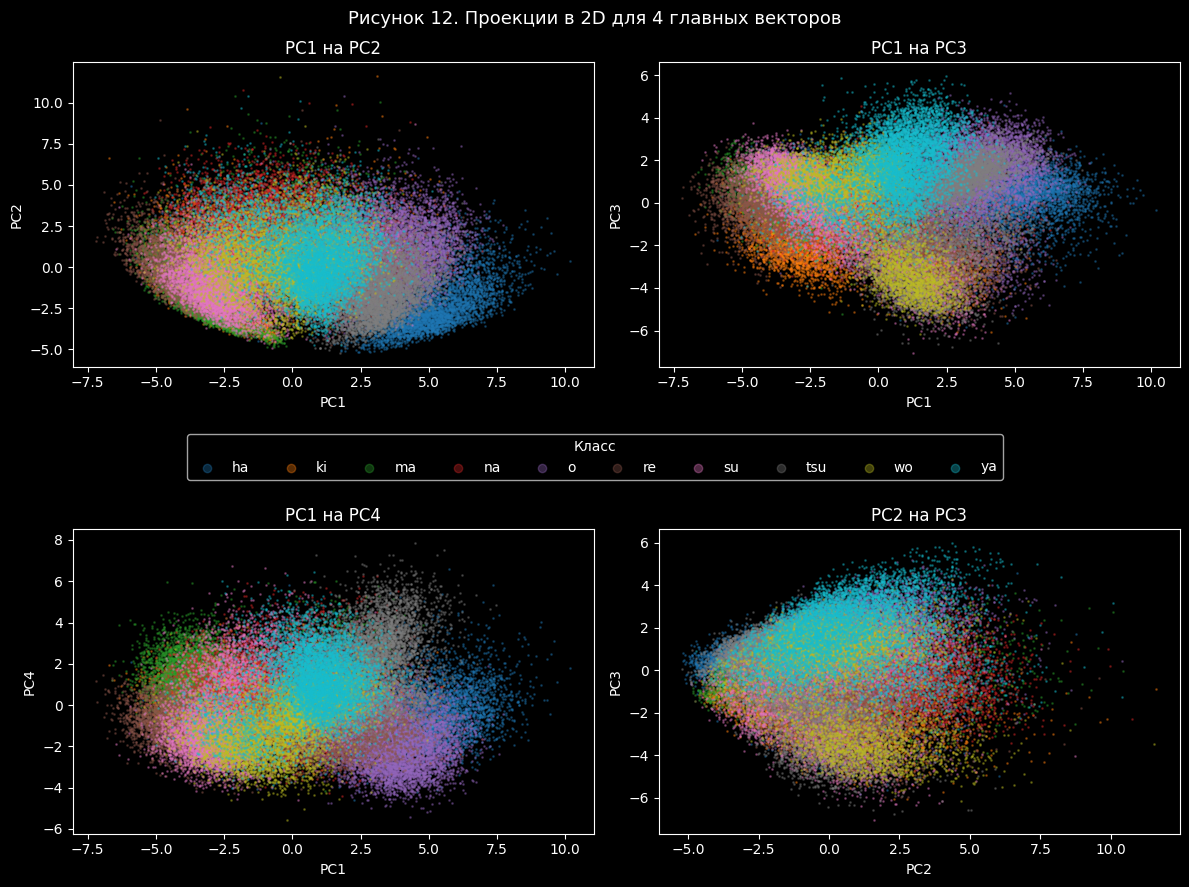

In [144]:
pairs = [(0, 1), (0, 2), (0, 3), (1, 2)]
pair_labels = [("PC1", "PC2"), ("PC1", "PC3"), ("PC1", "PC4"), ("PC2", "PC3")]

unique_classes = np.unique(y)
# цветовая карта tab10 рассчитана ровно на 10 контрастных оттенков — по одному на каждый класс
class_color = dict(zip(unique_classes, plt.get_cmap("tab10")(np.linspace(0, 1, len(unique_classes)))))
y_arr = np.array(y)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Рисунок 12. Проекции в 2D для 4 главных векторов", fontsize=13)

for ax, (xi, yi), (lx, ly) in zip(axes.flat, pairs, pair_labels):
    for cls in unique_classes:
        mask = y_arr == cls
        ax.scatter(pca_results[mask, xi], pca_results[mask, yi],
                   color=class_color[cls], s=1, alpha=0.35, label=cls)
    ax.set(xlabel=lx, ylabel=ly, title=f"{lx} на {ly}")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Класс",
           loc="lower center", ncol=len(unique_classes),
           bbox_to_anchor=(0.5, 0.45), markerscale=6,
           )


plt.tight_layout(h_pad=7)
plt.show()


#### Реконструкция от Антона Юрьевича

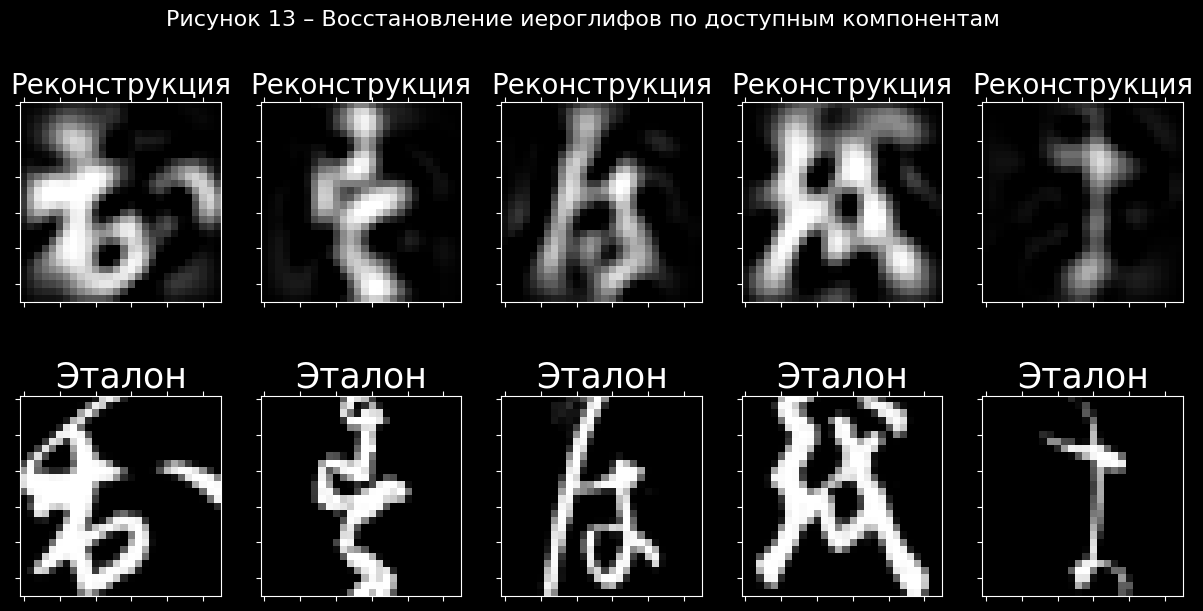

In [145]:
n = 3900 # номер иероглифа в датасете


fig=plt.figure(figsize=(15,7))
plt.suptitle("Рисунок 13 – Восстановление иероглифов по доступным компонентам", fontsize=16)
for i in range(0,5):
  ax = fig.add_subplot(2,5,i+1)
  ax.set_title("Реконструкция", size=20)
  ax.matshow(1-pca_inverse[i+n,:].reshape((28,28)).astype(float), cmap='Greys', vmin = 0, vmax = 1)
  plt.setp(ax.get_xticklabels(), visible=False)
  plt.setp(ax.get_yticklabels(), visible=False)

for i in range(0,5):
  ax = fig.add_subplot(2,5,i+6)
  ax.set_title("Эталон", size=25)
  ax.matshow(1-X.to_numpy()[i+n,:].reshape((28,28)).astype(float), cmap='Greys', vmin = 0, vmax = 1)
  plt.setp(ax.get_xticklabels(), visible=False)
  plt.setp(ax.get_yticklabels(), visible=False)

### Применение TSNE

#### (Гипер) Установим гиперпараметры

In [146]:
perplexity = widgets.IntSlider(
    step=1,
    disabled=False,
    value=25,
    min=1,
    max=100,
    style={"handle_style": "blue", "description_width": "initial"}
)

number_learning_iterations = widgets.IntSlider(
    step=1,
    disabled=False,
    value=100,
    min=1,
    max=2500,
    style={"handle_style": "blue", "description_width": "initial"},
)

display(perplexity, number_learning_iterations)

IntSlider(value=25, min=1, style=SliderStyle(description_width='initial'))

IntSlider(value=100, max=2500, min=1, style=SliderStyle(description_width='initial'))

In [ ]:
tsne = TSNE(n_components=2, 
            perplexity=perplexity.value, 
            n_iter_without_progress=number_learning_iterations.value,
            learning_rate='auto')

tsne_results = tsne.fit_transform(pca_results)

#### Двухмерная визуализация результатов

In [ ]:
px.scatter(
    tsne_results,
    x=0,
    y=1,
    color=y,
    labels={'color': 'иероглиф'},
    template="plotly_dark"
)